## Load Data

In [ ]:
import sys

sys.path.append("../src")

from preprocess import load_data, create_target, select_features, preprocess_features

/Users/AustinZhang/IDS583_Final_Project/notebooks/../src/preprocess.py:48: SyntaxWarning: invalid escape sequence '\d'
  df["term"] = df["term"].str.extract("(\d+)").astype(float)


In [2]:
df_raw = load_data("../data/raw/accepted_2007_to_2018Q4.csv")
df_raw.head()

/Users/AustinZhang/IDS583_Final_Project/notebooks/../src/preprocess.py:6: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_raw.shape

(2260701, 151)

## Target Construction & Feature Selection

In [3]:
df = create_target(df_raw)

/Users/AustinZhang/IDS583_Final_Project/notebooks/../src/preprocess.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["default"] = (df["loan_status"] == "Charged Off").astype(int)


In [4]:
df["default"].value_counts(normalize=True)

default
0    0.800374
1    0.199626
Name: proportion, dtype: float64

In [5]:
df = select_features(df)

## Missing Values

In [6]:
df.isnull().mean()

loan_amnt         0.000000
annual_inc        0.000000
fico_range_low    0.000000
dti               0.000278
emp_length        0.058359
home_ownership    0.000000
term              0.000000
purpose           0.000000
default           0.000000
dtype: float64

## Preprocessing

In [7]:
df = preprocess_features(df)
df.head()

,loan_amnt,annual_inc,fico_range_low,dti,emp_length,term,default,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,3600.0,55000.0,675.0,5.91,10.0,36.0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,24700.0,65000.0,715.0,16.06,10.0,36.0,0,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,20000.0,63000.0,695.0,10.78,10.0,60.0,0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
4,10400.0,104433.0,695.0,25.37,3.0,60.0,0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
5,11950.0,34000.0,690.0,10.20,4.0,36.0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# save the cleaned data
df.to_csv("../data/processed/loan_clean.csv", index=False)

## Stratified Split

In [ ]:
from split import *

X_train, X_test, y_train, y_test = train_test_split_data(df)

In [10]:
# Default rate check
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train default rate: 0.1996259226497982
Test default rate: 0.1996268518036735


In [11]:
# scaling features for logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [19]:
from model_pd import *

model = train_logistic(X_train_scaled, y_train)

# PD prediction
y_pred = predict_pd(model, X_test_scaled)

# evaluation
metrics = evaluate_model(y_test, y_pred)

print(metrics)

{'AUC': 0.6817217530031783, 'KS': 0.258900692072586}


The logistic regression model achieves an AUC of 0.68 and a KS statistic of 0.26, indicating moderate discriminatory power.

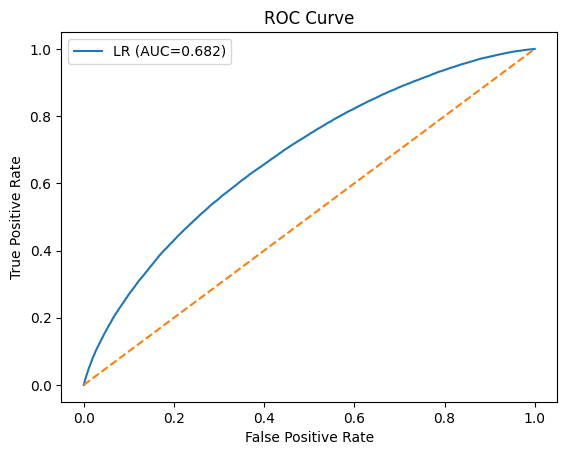

In [ ]:
# Roc curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label="LR (AUC=%.3f)" % metrics["AUC"])
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

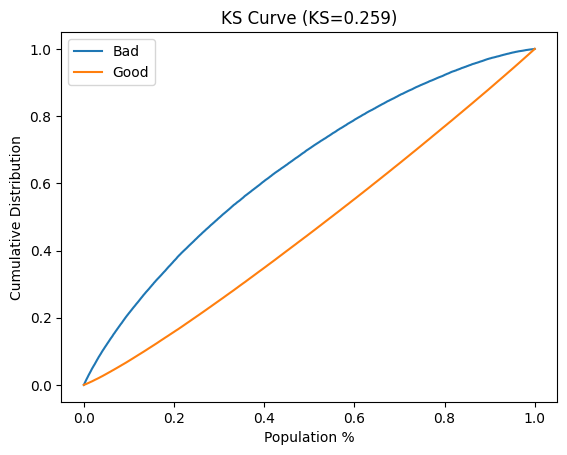

In [ ]:
# KS curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({"y": y_test, "pd": y_pred})

# sort
data = data.sort_values("pd", ascending=False)

# cumulative
data["cum_bad"] = data["y"].cumsum() / data["y"].sum()
data["cum_good"] = (1 - data["y"]).cumsum() / (1 - data["y"]).sum()

data["pct"] = np.arange(len(data)) / len(data)

# KS
ks = np.max(data["cum_bad"] - data["cum_good"])

# plot
plt.plot(data["pct"], data["cum_bad"], label="Bad")
plt.plot(data["pct"], data["cum_good"], label="Good")

plt.title(f"KS Curve (KS={ks:.3f})")
plt.xlabel("Population %")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.show()

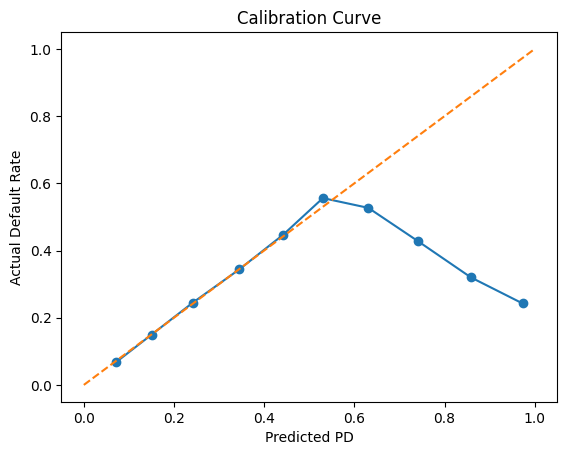

In [ ]:
# Calibration curve
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], "--")
plt.title("Calibration Curve")
plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.show()

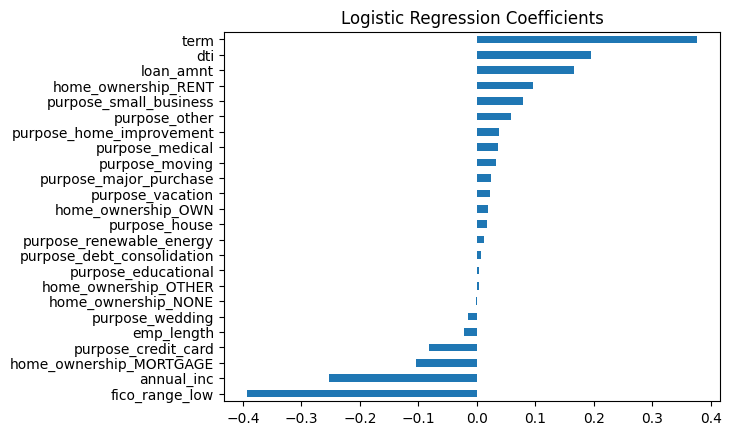

In [16]:
# feature importance
import pandas as pd

coef = pd.Series(model.coef_[0], index=X_train.columns)
coef = coef.sort_values()

coef.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.show()

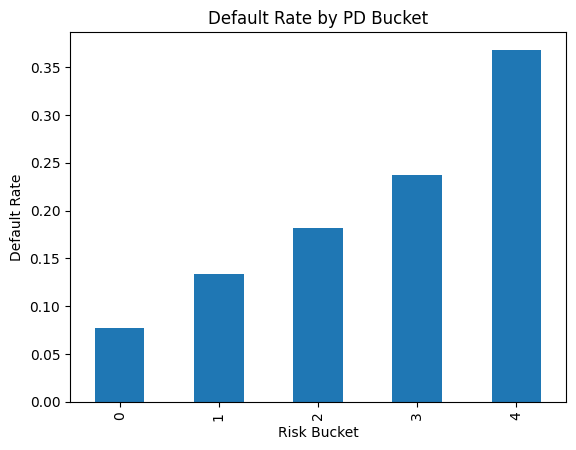

In [ ]:
# Risk Segmentation
df_test = pd.DataFrame({"PD": y_pred, "actual": y_test})

df_test["bucket"] = pd.qcut(df_test["PD"], 5, labels=False)

df_test.groupby("bucket")["actual"].mean().plot(kind="bar")

plt.title("Default Rate by PD Bucket")
plt.xlabel("Risk Bucket")
plt.ylabel("Default Rate")
plt.show()

In [31]:
df_test.to_csv("../data/processed/test_with_pd_bucket.csv", index=False)

# PD Output

In [24]:
# combine test data with predictions for further analysis
results = X_test.copy()
results["actual_default"] = y_test
results["predicted_pd"] = y_pred

results.head()

,loan_amnt,annual_inc,fico_range_low,dti,emp_length,term,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,...,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,actual_default,predicted_pd
2200605,15000.0,70000.0,695.0,21.12,10.0,36.0,False,False,False,True,...,False,False,False,False,False,False,False,False,0,0.171125
1279983,25000.0,60000.0,685.0,27.06,10.0,36.0,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0.167224
222290,1500.0,30000.0,675.0,7.16,1.0,36.0,False,False,False,False,...,False,False,False,False,False,False,False,False,0,0.153700
1266613,14000.0,95000.0,695.0,16.26,10.0,60.0,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0.238813
1903508,8575.0,25089.0,680.0,16.36,8.0,36.0,False,False,False,False,...,False,False,False,False,False,False,False,False,0,0.182733


In [25]:
results.to_csv("../data/processed/test_with_pd.csv", index=False)

## Model Restoration

In [ ]:
import joblib

joblib.dump(model, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']